# Challenge Sprint 3 — Estatística, Probabilidade e Regressão Linear

**Integrantes do grupo:**
- Nome Completo Aluno 1 — RM: 000000
- Nome Completo Aluno 2 — RM: 000000
- Nome Completo Aluno 3 — RM: 000000

**Base de dados:** `consumo.csv`

Dataset diário com 365 registros (ano de 2015) contendo temperatura média, mínima e máxima (°C), volume de chuva (mm), indicador de fim de semana e consumo (variável de interesse, em unidades de medição do sistema).

**Variável selecionada para as análises de probabilidade:** `consumo`
**Variáveis selecionadas para a regressão linear:** `temp_media` (variável explicativa) e `consumo` (variável resposta)

> Para os exercícios de probabilidade, assume-se que a variável `consumo` segue uma **Distribuição Normal** com média e desvio-padrão estimados a partir da amostra.

## 0. Importação das bibliotecas e carga dos dados

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Configuração visual dos gráficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
# Carregamento da base de dados
# Separador ';' e decimal '.' conforme o arquivo original
df = pd.read_csv("consumo.csv", sep=";", decimal=".")

print("Dimensões do dataset:", df.shape)
df.head()


Dimensões do dataset: (365, 7)


,data,temp_media,temp_min,temp_max,chuva,fds,consumo
0,01/01/2015,27.30,23.9,32.5,0.0,0,25461
1,02/01/2015,27.02,24.5,33.5,0.0,0,28972
2,03/01/2015,24.82,22.4,29.9,0.0,1,30814
3,04/01/2015,23.98,21.5,28.6,1.2,1,29799
4,05/01/2015,23.82,21.0,28.3,0.0,0,28900


In [3]:
# Checagem de qualidade dos dados: tipos e valores ausentes
print(df.dtypes)
print()
print("Valores ausentes por coluna:")
print(df.isna().sum())
print()
df.describe()


data              str
temp_media    float64
temp_min      float64
temp_max      float64
chuva         float64
fds             int64
consumo         int64
dtype: object

Valores ausentes por coluna:
data          0
temp_media    0
temp_min      0
temp_max      0
chuva         0
fds           0
consumo       0
dtype: int64



,temp_media,temp_min,temp_max,chuva,fds,consumo
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,21.226356,17.461370,26.611507,5.196712,0.284932,25401.367123
std,3.180108,2.826185,4.317366,12.417844,0.452001,4399.142703
min,12.900000,10.600000,14.500000,0.000000,0.000000,14343.000000
25%,19.020000,15.300000,23.800000,0.000000,0.000000,22008.000000
50%,21.380000,17.900000,26.900000,0.000000,0.000000,24867.000000
75%,23.280000,19.600000,29.400000,3.200000,1.000000,28631.000000
max,28.860000,24.500000,36.500000,94.800000,1.000000,37937.000000


**Observação:** o dataset não possui valores ausentes e todas as variáveis numéricas já estão em formato adequado (`float64`/`int64`), não sendo necessário nenhum tratamento adicional antes das análises.

## 1. Probabilidade acima da Mediana (2,5 pontos)

**Variável analisada:** `consumo`

Queremos calcular a probabilidade de o consumo diário ser **maior que a mediana** da variável, assumindo que `consumo ~ Normal(média, desvio-padrão)`.

In [4]:
# --- Cálculo da mediana ---
mediana_consumo = df["consumo"].median()
media_consumo = df["consumo"].mean()
desvio_consumo = df["consumo"].std(ddof=1)  # desvio padrão amostral

print(f"Média do consumo:   {media_consumo:.2f}")
print(f"Mediana do consumo: {mediana_consumo:.2f}")
print(f"Desvio-padrão:      {desvio_consumo:.2f}")


Média do consumo:   25401.37
Mediana do consumo: 24867.00
Desvio-padrão:      4399.14


In [5]:
# --- Cálculo da probabilidade P(consumo > mediana) ---
# Usamos a Normal ajustada com média e desvio-padrão da amostra (stats.norm.cdf)
p_acima_mediana = 1 - stats.norm.cdf(mediana_consumo, loc=media_consumo, scale=desvio_consumo)

print(f"P(consumo > mediana) = {p_acima_mediana:.4f}")
print(f"P(consumo > mediana) = {p_acima_mediana*100:.2f}%")


P(consumo > mediana) = 0.5483
P(consumo > mediana) = 54.83%


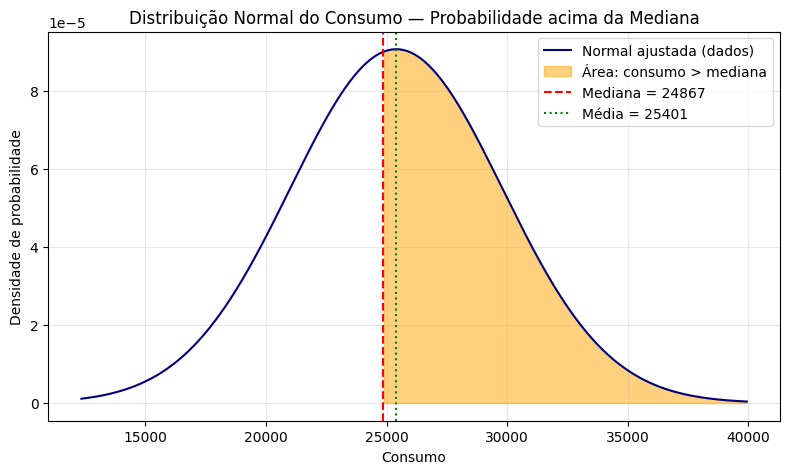

In [6]:
# --- Visualização: distribuição normal ajustada e a mediana ---
x_vals = np.linspace(df["consumo"].min() - 2000, df["consumo"].max() + 2000, 500)
y_vals = stats.norm.pdf(x_vals, loc=media_consumo, scale=desvio_consumo)

fig, ax = plt.subplots()
ax.plot(x_vals, y_vals, color="navy", label="Normal ajustada (dados)")
ax.fill_between(x_vals, y_vals, where=(x_vals > mediana_consumo),
                 color="orange", alpha=0.5, label="Área: consumo > mediana")
ax.axvline(mediana_consumo, color="red", linestyle="--", label=f"Mediana = {mediana_consumo:.0f}")
ax.axvline(media_consumo, color="green", linestyle=":", label=f"Média = {media_consumo:.0f}")
ax.set_title("Distribuição Normal do Consumo — Probabilidade acima da Mediana")
ax.set_xlabel("Consumo")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.tight_layout()
plt.savefig("ex1_probabilidade_mediana.png", dpi=150)
plt.show()


### Classificação do evento

| Faixa de probabilidade | Classificação |
|---|---|
| p < 5% | Raro |
| 5% ≤ p < 40% | Pouco provável |
| 40% ≤ p < 90% | Provável |
| p ≥ 90% | Quase certo |

Como a probabilidade calculada foi de aproximadamente **54,8%**, o evento *"consumo diário acima da mediana"* é classificado como **PROVÁVEL**.

Isso ocorre porque a distribuição do consumo apresenta uma leve assimetria à direita (a média é um pouco maior que a mediana), o que faz com que a probabilidade, sob a Normal ajustada, fique levemente acima de 50%.

## 2. Probabilidade no Intervalo (média ± 2 desvios-padrão) (2,5 pontos)

Queremos calcular a probabilidade de o consumo diário estar dentro do intervalo **[média − 2σ, média + 2σ]**, assumindo `consumo ~ Normal(média, desvio-padrão)`.

In [7]:
# --- Cálculo da média, desvio-padrão e limites do intervalo ---
limite_inferior = media_consumo - 2 * desvio_consumo
limite_superior = media_consumo + 2 * desvio_consumo

print(f"Média:              {media_consumo:.2f}")
print(f"Desvio-padrão:       {desvio_consumo:.2f}")
print(f"Limite inferior (média - 2s): {limite_inferior:.2f}")
print(f"Limite superior (média + 2s): {limite_superior:.2f}")


Média:              25401.37
Desvio-padrão:       4399.14
Limite inferior (média - 2s): 16603.08
Limite superior (média + 2s): 34199.65


In [8]:
# --- Cálculo da probabilidade do intervalo ---
p_intervalo = (stats.norm.cdf(limite_superior, loc=media_consumo, scale=desvio_consumo)
               - stats.norm.cdf(limite_inferior, loc=media_consumo, scale=desvio_consumo))

print(f"P({limite_inferior:.0f} < consumo < {limite_superior:.0f}) = {p_intervalo:.4f}")
print(f"P(média - 2s < consumo < média + 2s) = {p_intervalo*100:.2f}%")


P(16603 < consumo < 34200) = 0.9545
P(média - 2s < consumo < média + 2s) = 95.45%


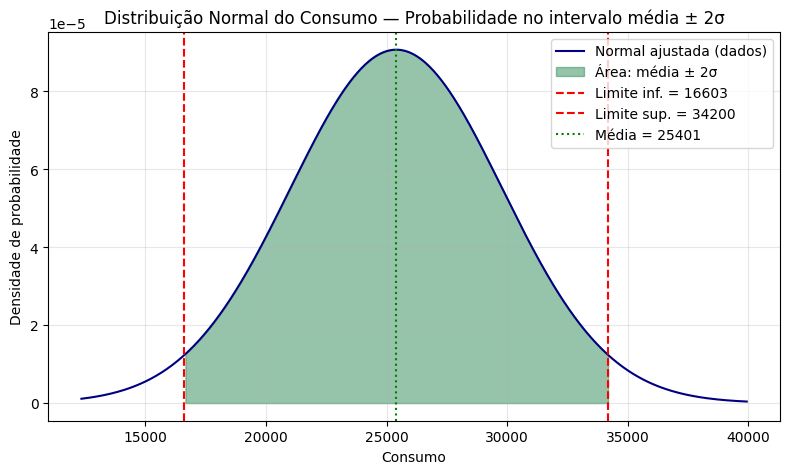

In [9]:
# --- Visualização do intervalo média +/- 2 desvios-padrão ---
fig, ax = plt.subplots()
ax.plot(x_vals, y_vals, color="navy", label="Normal ajustada (dados)")
ax.fill_between(x_vals, y_vals,
                 where=(x_vals > limite_inferior) & (x_vals < limite_superior),
                 color="seagreen", alpha=0.5, label="Área: média ± 2σ")
ax.axvline(limite_inferior, color="red", linestyle="--", label=f"Limite inf. = {limite_inferior:.0f}")
ax.axvline(limite_superior, color="red", linestyle="--", label=f"Limite sup. = {limite_superior:.0f}")
ax.axvline(media_consumo, color="green", linestyle=":", label=f"Média = {media_consumo:.0f}")
ax.set_title("Distribuição Normal do Consumo — Probabilidade no intervalo média ± 2σ")
ax.set_xlabel("Consumo")
ax.set_ylabel("Densidade de probabilidade")
ax.legend()
plt.tight_layout()
plt.savefig("ex2_probabilidade_intervalo.png", dpi=150)
plt.show()


### Classificação do evento

A probabilidade obtida foi de aproximadamente **95,4%**, valor muito próximo do resultado teórico esperado para qualquer distribuição Normal (≈ 95,45% dos dados dentro de média ± 2 desvios-padrão, conforme a *regra empírica* / regra 68-95-99,7).

Esse resultado classifica o evento *"consumo diário dentro do intervalo média ± 2σ"* como **QUASE CERTO**.

## 3. Modelagem com Regressão Linear (3,0 pontos)

**Variáveis selecionadas:**
- Variável explicativa (X): `temp_media` (temperatura média diária, em °C)
- Variável resposta (Y): `consumo`

**Hipótese:** dias mais quentes tendem a apresentar maior consumo (por exemplo, devido ao uso mais intenso de sistemas de refrigeração).

In [10]:
# --- Preparação dos dados para o modelo ---
X = df[["temp_media"]].values   # variável explicativa (precisa ser 2D para o sklearn)
y = df["consumo"].values        # variável resposta

# --- Ajuste do modelo de Regressão Linear ---
modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

coef_angular = modelo.coef_[0]
intercepto = modelo.intercept_
r2 = modelo.score(X, y)
correlacao = df["temp_media"].corr(df["consumo"])

print(f"Coeficiente angular (inclinação): {coef_angular:.4f}")
print(f"Intercepto:                       {intercepto:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Coeficiente de correlação (r):    {correlacao:.4f}")
print()
print(f"Equação do modelo: consumo = {intercepto:.2f} + {coef_angular:.2f} * temp_media")


Coeficiente angular (inclinação): 794.8825
Intercepto:                       8528.9073
Coeficiente de determinação (R²): 0.3302
Coeficiente de correlação (r):    0.5746

Equação do modelo: consumo = 8528.91 + 794.88 * temp_media


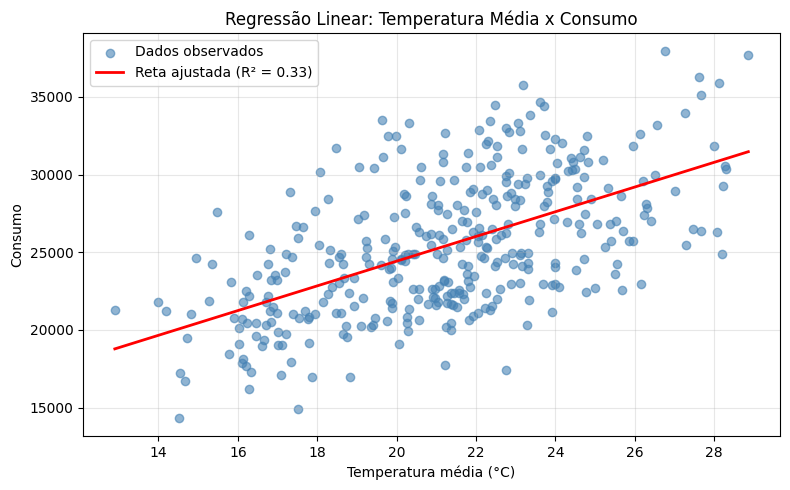

In [11]:
# --- Gráfico: dispersão dos dados e reta ajustada ---
fig, ax = plt.subplots()
ax.scatter(df["temp_media"], df["consumo"], alpha=0.6, color="steelblue", label="Dados observados")

ordem = np.argsort(df["temp_media"].values)
ax.plot(df["temp_media"].values[ordem], y_pred[ordem], color="red", linewidth=2,
        label=f"Reta ajustada (R² = {r2:.2f})")

ax.set_title("Regressão Linear: Temperatura Média x Consumo")
ax.set_xlabel("Temperatura média (°C)")
ax.set_ylabel("Consumo")
ax.legend()
plt.tight_layout()
plt.savefig("ex3_regressao_linear.png", dpi=150)
plt.show()


### Interpretação dos coeficientes

- **Coeficiente angular (≈ 794,88):** para cada aumento de 1°C na temperatura média diária, o consumo tende a aumentar, em média, aproximadamente **795 unidades**, mantendo-se as demais condições constantes. O sinal positivo confirma a relação direta esperada entre temperatura e consumo.
- **Intercepto (≈ 8.528,91):** representa o consumo estimado pelo modelo quando a temperatura média é 0°C — valor sem significado prático direto neste contexto (fora da faixa observada de temperaturas), servindo apenas como parâmetro matemático da reta.
- **R² (≈ 0,33):** aproximadamente 33% da variação do consumo diário é explicada apenas pela variação da temperatura média. Isso indica uma relação **moderada**, não muito forte — ou seja, a temperatura influencia o consumo, mas outros fatores (chuva, fim de semana, sazonalidade, etc.) também têm papel relevante que não é capturado por este modelo simples.
- **Correlação de Pearson (≈ 0,57):** confirma uma associação linear **positiva e moderada** entre as duas variáveis.

## 4. Organização, clareza e interpretação geral (2,0 pontos)

### Resumo das análises realizadas

| Análise | Resultado | Classificação |
|---|---|---|
| P(consumo > mediana) | ≈ 54,83% | Provável |
| P(média − 2σ < consumo < média + 2σ) | ≈ 95,45% | Quase certo |
| Regressão Linear (temp_media → consumo) | R² ≈ 0,33 / r ≈ 0,57 | Relação moderada e positiva |

### Relação entre estatística e aprendizado de máquina

Os exercícios desta sprint conectam conceitos centrais de estatística descritiva/probabilística com técnicas fundamentais de Machine Learning:

- O cálculo de **média, mediana e desvio-padrão** é a base para entender a forma de uma distribuição, e é justamente esse tipo de estatística que orienta etapas de **pré-processamento** (normalização, detecção de outliers, etc.) em pipelines de aprendizado de máquina.
- A **regra empírica da distribuição Normal** (≈ 95% dos dados dentro de média ± 2σ) é amplamente usada, por exemplo, na **detecção de anomalias**: valores fora desse intervalo podem ser tratados como outliers em um modelo.
- A **Regressão Linear**, aplicada aqui de forma simples (uma variável explicativa), é o algoritmo supervisionado mais básico de Machine Learning, servindo como porta de entrada para modelos mais complexos (regressão múltipla, regressão polinomial, redes neurais). O **R²** é justamente a métrica que se usa para avaliar o quão bem um modelo de regressão explica a variabilidade dos dados — quanto mais próximo de 1, melhor o ajuste.
- O fato de o R² ter sido moderado (≈ 0,33) ilustra, na prática, por que modelos reais de Machine Learning normalmente utilizam **múltiplas variáveis explicativas** (aqui, além da temperatura, poderíamos incluir chuva e fim de semana) para capturar melhor a variação do fenômeno estudado.

### Conclusão

A análise mostrou que o consumo diário se comporta de forma compatível com uma distribuição aproximadamente Normal, com leve assimetria positiva. A temperatura média é uma variável explicativa relevante, mas não suficiente isoladamente, para prever o consumo com alta precisão — reforçando a importância de, em projetos futuros de Machine Learning, considerar múltiplas variáveis (regressão múltipla) para melhorar a capacidade preditiva do modelo.